h          | D_Forward  | Err_Forward | D_Back     | Err_Back   | D_Center   | Err_Center
-----------------------------------------------------------------------------------------------
1.0e+00 | -2.237500 | 1.33e+00 | -0.287500 | 6.25e-01 | -1.262500 | 3.50e-01
1.0e-01 | -1.003600 | 9.11e-02 | -0.828400 | 8.41e-02 | -0.916000 | 3.50e-03
1.0e-02 | -0.921285 | 8.79e-03 | -0.903785 | 8.72e-03 | -0.912535 | 3.50e-05
1.0e-03 | -0.913375 | 8.75e-04 | -0.911625 | 8.75e-04 | -0.912500 | 3.50e-07
1.0e-04 | -0.912588 | 8.75e-05 | -0.912413 | 8.75e-05 | -0.912500 | 3.50e-09
1.0e-05 | -0.912509 | 8.75e-06 | -0.912491 | 8.75e-06 | -0.912500 | 3.32e-11
1.0e-06 | -0.912501 | 8.75e-07 | -0.912499 | 8.75e-07 | -0.912500 | 5.42e-12
1.0e-07 | -0.912500 | 8.66e-08 | -0.912500 | 8.77e-08 | -0.912500 | 5.50e-10
1.0e-08 | -0.912500 | 8.89e-09 | -0.912500 | 2.22e-09 | -0.912500 | 3.34e-09
1.0e-09 | -0.912500 | 3.55e-08 | -0.912500 | 7.55e-08 | -0.912500 | 2.00e-08
1.0e-10 | -0.912500 | 7.55e-08 | -0.912500 |

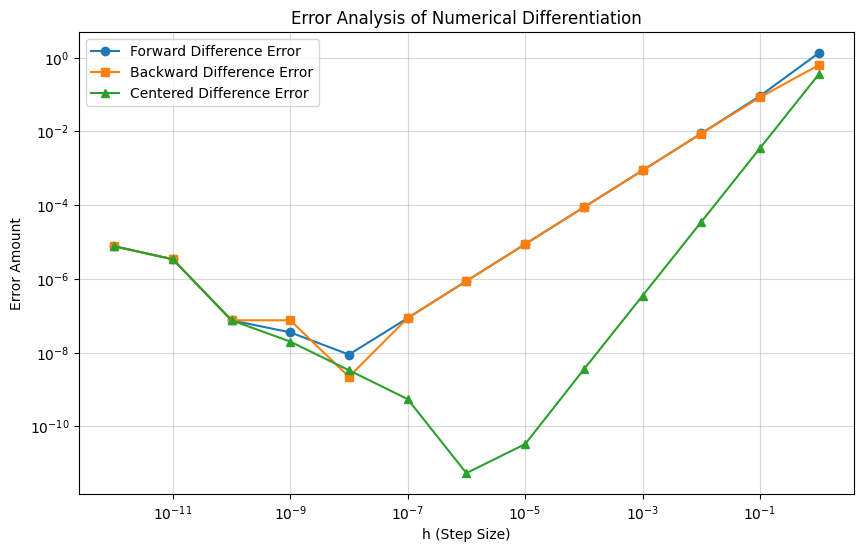


--- Taylor Series Results (e^1) ---
n    | Pn(x)        | Relative Error (%)
0    | 1.00000000 | 6.32e+01%
1    | 2.00000000 | 2.64e+01%
2    | 2.50000000 | 8.03e+00%
3    | 2.66666667 | 1.90e+00%
4    | 2.70833333 | 3.66e-01%
5    | 2.71666667 | 5.94e-02%
6    | 2.71805556 | 8.32e-03%
7    | 2.71825397 | 1.02e-03%
8    | 2.71827877 | 1.13e-04%
9    | 2.71828153 | 1.11e-05%
10   | 2.71828180 | 1.00e-06%

--- Numerical Stability Results ---
Direct Product: 0.0
Log-Sum (Log10): -820.0
Status: Underflow detected in direct product.

--- Variance Precision Results ---
Naive Variance:  -1.8446744073626216e+16
Stable Variance: 83333.25


In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import math 

# --- TASK 1: Numerical Differentiation Analysis ---
# Comparing Forward, Backward, and Centered difference methods.
# Demonstrates Truncation Error vs. Round-off Error.

def f(x):
    return -0.1 * x**4 - 0.15 * x**3 - 0.5 * x**2 - 0.25 * x + 1.2

x0 = 0.5
f_prime_ref = -0.9125 # Analytical derivative at x=0.5

def d_forward(f, x, h):
    return (f(x + h) - f(x)) / h

def d_backward(f, x, h):
    return (f(x) - f(x - h)) / h

def d_centered(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

h_values = 10.0**np.arange(0, -13, -1)
results = []

for h in h_values:
    df_f = d_forward(f, x0, h)
    df_b = d_backward(f, x0, h)
    df_c = d_centered(f, x0, h)
    
    e_f = abs(f_prime_ref - df_f)
    e_b = abs(f_prime_ref - df_b)
    e_c = abs(f_prime_ref - df_c)
    
    results.append([h, df_f, e_f, df_b, e_b, df_c, e_c])

results = np.array(results)    

print(f"{'h':<10} | {'D_Forward':<10} | {'Err_Forward':<10} | {'D_Back':<10} | {'Err_Back':<10} | {'D_Center':<10} | {'Err_Center':<10}")
print("-" * 95)
for row in results:
    print(f"{row[0]:.1e} | {row[1]:.6f} | {row[2]:.2e} | {row[3]:.6f} | {row[4]:.2e} | {row[5]:.6f} | {row[6]:.2e}")

# Plotting the Errors
plt.figure(figsize=(10, 6))
plt.loglog(h_values, results[:, 2], label='Forward Difference Error', marker='o')
plt.loglog(h_values, results[:, 4], label='Backward Difference Error', marker='s')
plt.loglog(h_values, results[:, 6], label='Centered Difference Error', marker='^')
plt.xlabel('h (Step Size)')
plt.ylabel('Error Amount')
plt.title('Error Analysis of Numerical Differentiation')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# --- TASK 2: Taylor Series Approximation ---
# Approximating e^x at x=1 (Maclaurin Series)
# Demonstrates how Truncation Error decreases as the degree 'n' increases.

true_value = np.exp(1)
n_values = np.arange(0, 11)
approx_values = []
errors = []
current_sum = 0

print("\n--- Taylor Series Results (e^1) ---")
print(f"{'n':<4} | {'Pn(x)':<12} | {'Relative Error (%)'}")
for n in n_values:
    term = (1**n) / math.factorial(n)
    current_sum += term
    rel_error = abs(true_value - current_sum) / true_value * 100
    
    approx_values.append(current_sum)
    errors.append(rel_error)
    print(f"{n:<4} | {current_sum:.8f} | {rel_error:.2e}%")

# --- TASK 3: Underflow and Log-Domain ---
# Demonstrates numerical stability when multiplying many small probabilities.

i_probs = np.arange(1, 41)
p_values = 10.0**(-i_probs)

# Direct product (Will likely Underflow to 0)
direct_product = np.prod(p_values)

# Log-domain sum
log_sum = np.sum(np.log10(p_values))

print("\n--- Numerical Stability Results ---")
print(f"Direct Product: {direct_product}")
print(f"Log-Sum (Log10): {log_sum}")
if direct_product == 0:
    print("Status: Underflow detected in direct product.")

# --- TASK 4: Variance Calculation and Cancellation Error ---
# Demonstrates why the 'shifted' variance formula is more stable.

N = 1000
data = 10**8 + np.arange(1, N + 1) # Large numbers close together

# Naive Formula (Prone to Catastrophic Cancellation)
var_naive = (np.sum(data**2) / N) - (np.sum(data) / N)**2

# Stable Formula (Two-pass)
mean_val = np.mean(data)
var_stable = np.mean((data - mean_val)**2)

print("\n--- Variance Precision Results ---")
print(f"Naive Variance:  {var_naive}")
print(f"Stable Variance: {var_stable}")